# 11b — Capacity Analysis: Momentum Strategy

Parallel to NB11. Momentum has **higher turnover** (28.0% vs 19.2%/month),
which means **lower capacity** at any given participation threshold.
This notebook quantifies the capacity difference.

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import rankdata

from src.data_loader import load_signal_data, FACTOR_COLUMNS, INDUSTRIES, COUNTRY_TC_BPS, DEFAULT_TC_BPS

OUTPUT_DIR = '../output'
HOLD_START = pd.Timestamp('2019-01-01')
REALISTIC_TC_BPS = 45.0

def ann_sharpe(s):
    s = s.dropna()
    if len(s) < 6 or s.std() == 0: return np.nan
    return s.mean()*12 / (s.std()*np.sqrt(12))
def ann_ret(s): return s.dropna().mean() * 12
def ann_vol(s): return s.dropna().std() * np.sqrt(12)
def max_dd(s):
    cum = (1 + s.dropna()).cumprod()
    return float((cum / cum.cummax() - 1).min())
df = load_signal_data('../data')
df = df.sort_values(['ym', 'ric'])
hdf = pd.read_csv(f'{OUTPUT_DIR}/csv/nb09_hedged_returns.csv', index_col=0, parse_dates=True)

stock_to = 0.1842; pc_to_mom = 0.0959
total_to_mom = stock_to + pc_to_mom  # 0.2801
total_to_mvo = 0.1916

print(f'Momentum turnover: {total_to_mom:.3f}/mo ({total_to_mom*12:.1f}x annual)')
print(f'TO_MVO turnover: {total_to_mvo:.3f}/mo ({total_to_mvo*12:.1f}x annual)')
print(f'Momentum/TO_MVO ratio: {total_to_mom/total_to_mvo:.2f}x')

  Dropped 12 duplicate (ric, ym) rows
Signal data loaded: 98,742 rows x 51 cols | 2004-01 to 2025-03
Momentum turnover: 0.280/mo (3.4x annual)
TO_MVO turnover: 0.192/mo (2.3x annual)
Momentum/TO_MVO ratio: 1.46x


## 1. Holdings & ADV

In [2]:
ret_col = 'mret_bbg'
df_oos = df[df['ym'] >= '2009-02'].copy()
df_oos['adv_usd'] = df_oos['share_turnover_t'] * df_oos['prc'] * df_oos['fx_rate'] / 21

all_holdings = []
for ym in sorted(df_oos['ym'].unique()):
    month_df = df_oos[df_oos['ym'] == ym].copy()
    for ind in INDUSTRIES:
        ind_df = month_df[month_df['industry'] == ind].copy()
        if len(ind_df) < 5: continue
        valid_factors = [f for f in FACTOR_COLUMNS if ind_df[f].notna().sum() >= 5]
        if not valid_factors: continue
        for f in valid_factors:
            ind_df[f'{f}_rank'] = rankdata(ind_df[f].fillna(ind_df[f].median()))
        ind_df['composite'] = sum(ind_df[f'{f}_rank'] for f in valid_factors) / len(valid_factors)
        n = len(ind_df)
        top_frac = 0.2 if n >= 15 else 0.33
        cutoff = ind_df['composite'].quantile(1 - top_frac)
        selected = ind_df[ind_df['composite'] >= cutoff]
        if len(selected) == 0: continue
        wt = 1.0 / (len(selected) * len(INDUSTRIES))
        for _, row in selected.iterrows():
            all_holdings.append({'ym': ym, 'ric': row['ric'], 'country': row.get('country','Unknown'),
                                 'industry': ind, 'weight': wt, 'adv_usd': row.get('adv_usd', np.nan)})

holdings = pd.DataFrame(all_holdings)
hold_h = holdings[holdings['ym'] >= HOLD_START.strftime('%Y-%m')].copy()
print(f'Holdings: {len(hold_h)} stock-months, median ADV: ${hold_h["adv_usd"].median():,.0f}/day')

Holdings: 7499 stock-months, median ADV: $36,475/day


## 2. Capacity Comparison: Momentum vs TO\_MVO

In [3]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25]

print('CAPACITY COMPARISON: Momentum vs TO_MVO')
print('='*90)
print(f'{"Threshold":>10s} {"Mom Conservative":>16s} {"MVO Conservative":>16s} {"Mom 10th":>10s} {"MVO 10th":>10s} {"Mom Median":>12s} {"MVO Median":>12s}')
print('-'*90)

for thresh in thresholds:
    caps_mom = []; caps_mvo = []
    for ym in sorted(hold_h['ym'].unique()):
        m = hold_h[hold_h['ym'] == ym].dropna(subset=['adv_usd'])
        if len(m) == 0: continue
        m['max_aum_mom'] = m['adv_usd'] * thresh / (m['weight'] * total_to_mom / 21)
        m['max_aum_mvo'] = m['adv_usd'] * thresh / (m['weight'] * total_to_mvo / 21)
        caps_mom.append({'min': m['max_aum_mom'].min()/1e6, 'p10': m['max_aum_mom'].quantile(0.1)/1e6,
                         'med': m['max_aum_mom'].median()/1e6})
        caps_mvo.append({'min': m['max_aum_mvo'].min()/1e6, 'p10': m['max_aum_mvo'].quantile(0.1)/1e6,
                         'med': m['max_aum_mvo'].median()/1e6})
    
    df_m = pd.DataFrame(caps_mom); df_v = pd.DataFrame(caps_mvo)
    print(f'{thresh:>9.0%} {df_m["min"].mean():>14.0f}M {df_v["min"].mean():>14.0f}M '
          f'{df_m["p10"].mean():>8.0f}M {df_v["p10"].mean():>8.0f}M '
          f'{df_m["med"].mean():>10.0f}M {df_v["med"].mean():>10.0f}M')

print(f'\n  Capacity ratio (TO_MVO/Momentum) = {total_to_mom/total_to_mvo:.2f}x across all tiers')
print(f'  → TO_MVO can run {(total_to_mom/total_to_mvo-1)*100:.0f}% more AUM than Momentum')

CAPACITY COMPARISON: Momentum vs TO_MVO
 Threshold Mom Conservative MVO Conservative   Mom 10th   MVO 10th   Mom Median   MVO Median
------------------------------------------------------------------------------------------
       5%              1M              1M        4M        5M         17M         25M


      10%              1M              2M        7M       10M         35M         51M
      15%              2M              3M       11M       16M         52M         76M


      20%              3M              4M       14M       21M         70M        102M
      25%              3M              5M       18M       26M         87M        127M

  Capacity ratio (TO_MVO/Momentum) = 1.46x across all tiers
  → TO_MVO can run 46% more AUM than Momentum


## 3. Sharpe Degradation: Both Strategies

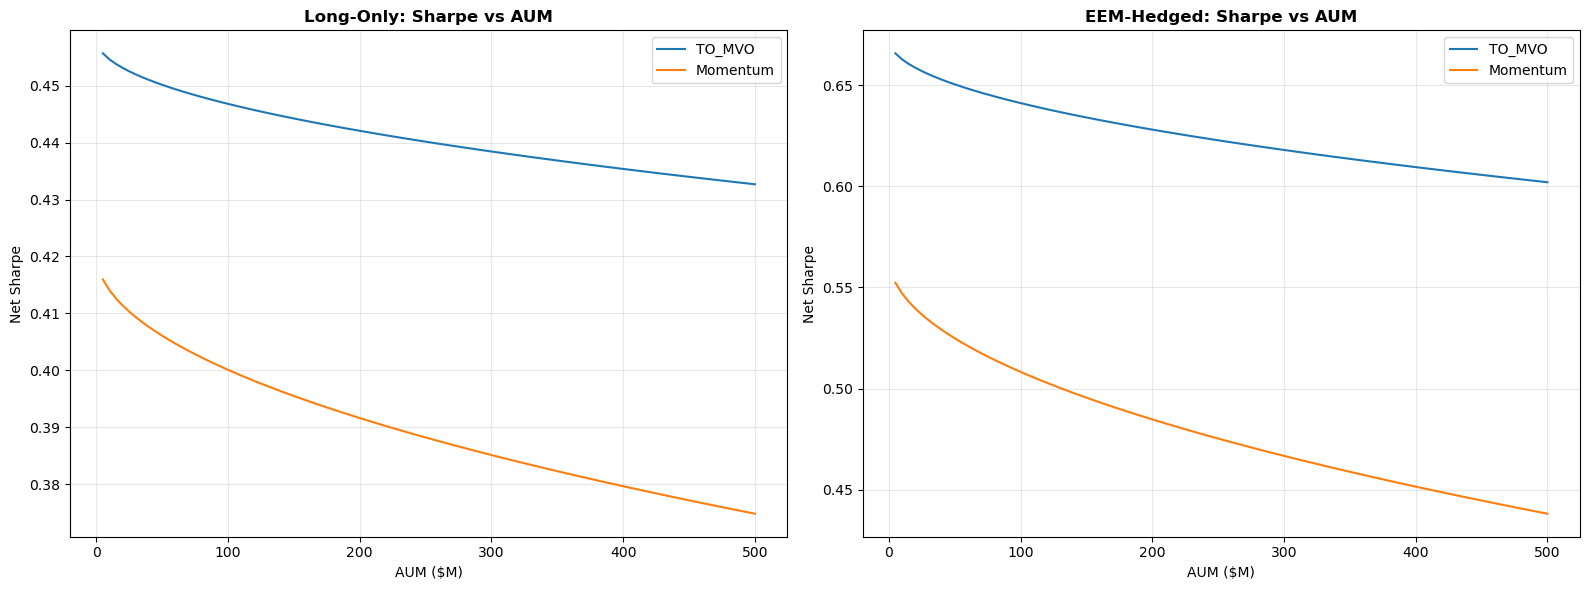


SHARPE AT VARIOUS AUM (k=0.3, base TC=45bp)
     AUM   MVO LO   Mom LO  MVO Hdg  Mom Hdg
    10M   0.455   0.414   0.663   0.547
    25M   0.453   0.410   0.657   0.537
    50M   0.450   0.406   0.651   0.525
   100M   0.447   0.400   0.641   0.508
   200M   0.442   0.392   0.628   0.485
   500M   0.433   0.375   0.602   0.438


In [4]:
lo_a = hdf['A_long'].dropna(); lo_a_h = lo_a[lo_a.index >= HOLD_START]
lo_b = hdf['B_long'].dropna(); lo_b_h = lo_b[lo_b.index >= HOLD_START]
hd_a = hdf['A_hedged_eem'].dropna(); hd_a_h = hd_a[hd_a.index >= HOLD_START]
hd_b = hdf['B_hedged_eem'].dropna(); hd_b_h = hd_b[hd_b.index >= HOLD_START]

total_adv = hold_h.groupby('ym')['adv_usd'].apply(lambda g: g.dropna().sum()).mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
aum_range = np.arange(5, 501, 5)
k = 0.3

for ax_idx, (title, pairs) in enumerate([
    ('Long-Only', [(lo_a_h, total_to_mvo, 'TO_MVO'), (lo_b_h, total_to_mom, 'Momentum')]),
    ('EEM-Hedged', [(hd_a_h, total_to_mvo, 'TO_MVO'), (hd_b_h, total_to_mom, 'Momentum')])]):
    ax = axes[ax_idx]
    for ret_h, to, label in pairs:
        sharpes = []
        for aum in aum_range:
            part = (aum*1e6*to/21) / total_adv if total_adv > 0 else 1
            impact = k * np.sqrt(part) * 100
            drag = to * (45 + impact) / 10000
            sharpes.append(ann_sharpe(ret_h - drag))
        ax.plot(aum_range, sharpes, lw=1.5, label=label)
    ax.set_xlabel('AUM ($M)'); ax.set_ylabel('Net Sharpe')
    ax.set_title(f'{title}: Sharpe vs AUM', fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/figures/nb11b_sharpe_comparison.pdf', bbox_inches='tight'); plt.show()

# Table
print('\nSHARPE AT VARIOUS AUM (k=0.3, base TC=45bp)')
print(f'{"AUM":>8s} {"MVO LO":>8s} {"Mom LO":>8s} {"MVO Hdg":>8s} {"Mom Hdg":>8s}')
for aum in [10, 25, 50, 100, 200, 500]:
    row = f'{aum:>6d}M'
    for ret_h, to in [(lo_a_h, total_to_mvo), (lo_b_h, total_to_mom),
                       (hd_a_h, total_to_mvo), (hd_b_h, total_to_mom)]:
        part = (aum*1e6*to/21) / total_adv if total_adv > 0 else 1
        impact = k * np.sqrt(part) * 100
        drag = to * (45 + impact) / 10000
        row += f' {ann_sharpe(ret_h - drag):>7.3f}'
    print(row)

## 4. Dollar P&L Comparison

In [5]:
print('REALISTIC DOLLAR P&L COMPARISON (k=0.3 impact, TC=45bp)')
print('='*80)
for aum_init in [10, 50, 100]:
    print(f'\n  Initial AUM = ${aum_init}M')
    for name, ret_h, to in [('TO_MVO', hd_a_h, total_to_mvo), ('Momentum', hd_b_h, total_to_mom)]:
        part = (aum_init*1e6*to/21) / total_adv if total_adv > 0 else 1
        impact = k * np.sqrt(part) * 100
        drag = to * (45 + impact) / 10000
        net = ret_h - drag
        cum = (1 + net).prod()
        total_ret = cum - 1
        ann_r = (cum ** (12/len(net))) - 1
        print(f'    {name:10s}: cum={total_ret:.1%}, ann={ann_r:.1%}, Sharpe={ann_sharpe(net):.3f}, '
              f'final=${aum_init*cum:.1f}M (P&L=${aum_init*total_ret:.1f}M)')

REALISTIC DOLLAR P&L COMPARISON (k=0.3 impact, TC=45bp)

  Initial AUM = $10M
    TO_MVO    : cum=27.3%, ann=4.3%, Sharpe=0.663, final=$12.7M (P&L=$2.7M)
    Momentum  : cum=21.4%, ann=3.4%, Sharpe=0.547, final=$12.1M (P&L=$2.1M)

  Initial AUM = $50M
    TO_MVO    : cum=26.7%, ann=4.2%, Sharpe=0.651, final=$63.3M (P&L=$13.3M)
    Momentum  : cum=20.4%, ann=3.3%, Sharpe=0.525, final=$60.2M (P&L=$10.2M)

  Initial AUM = $100M
    TO_MVO    : cum=26.2%, ann=4.1%, Sharpe=0.641, final=$126.2M (P&L=$26.2M)
    Momentum  : cum=19.7%, ann=3.2%, Sharpe=0.508, final=$119.7M (P&L=$19.7M)
